## Structured Output

in langchain strutured output reders to the practice of having language models return responsed in a well defined data format(for eg. json) rather than free form text. This make the model output easier to parse and work with prgrammatically

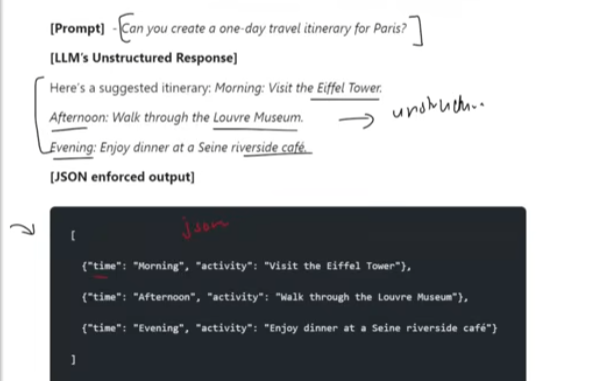

### Why do we need Structure Output
1. Data extraction
2. API building
3. Agents

## Ways to get Structured Output

Some LLMs can give, some cant give Structred output

1. LLMs those can : we can use the with_strutured_output
2. LLMs those cant : using output parsers

# 1. using with_sturtured_output

### A. TypedDict :
 TypeDict is wat to define a dictionary in python where you specify what keys ans values should exist. It helps ensure that you dictionary follows a specific structure

##### Why use TypeDict?
- It tells python what keys are required and what types of values they should have
- It does not validate data at runtime(it just helps with type hints for better coding)

In [3]:
from typing import TypedDict

class person(TypedDict):
    name : str
    age : int
    
new_person : person = {
    "name" : "Alice",
    "age" : '30'
}

print(new_person)


{'name': 'Alice', 'age': '30'}


We have reviews after LLM it should give summary and sentiment

In [9]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv  
from typing import TypedDict, Annotated
import os

load_dotenv()  # Load environment variables from .env file

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

# Pass llm into ChatHuggingFace
model = ChatHuggingFace(llm=llm)

class Review(TypedDict):
    summary : Annotated[str, "A brief summary of the review"]
    sentiment : Annotated[str, "The sentiment of the review (positive, negative, or neutral)"]
    
structured_output = model.with_structured_output(Review)

result = structured_output.invoke(""""I absolutely loved this product. The build quality is excellent, the performance is smooth, and it exceeded my expectations. Definitely worth the price!""")

print(result['summary'])
print(result['sentiment'])


I absolutely loved this product. The build quality is excellent, the performance is smooth, and it exceeded my expectations. Definitely worth the price!
positive


In [14]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv  
from typing import TypedDict, Annotated, Optional, Literal
import os

load_dotenv()  # Load environment variables from .env file

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

# Pass llm into ChatHuggingFace
model = ChatHuggingFace(llm=llm)

class Review(TypedDict):
    key_themes : Annotated[list[str], "The main themes discussed in the review"]
    summary : Annotated[str, "A brief summary of the review"]
    sentiment : Annotated[Literal["pos", "neg", "neu"], "The sentiment of the review (positive, negative, or neutral)"]
    props : Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons : Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    
structured_output = model.with_structured_output(Review)

result = structured_output.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don’t use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:
Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors""")

# print(result)
print(result['summary'])
print(result['key_themes'])
print(result['sentiment'])


The Samsung Galaxy S24 Ultra is a powerhouse with a fast processor, great camera, and long battery life, but its size and weight make it uncomfortable to use with one hand and it has bloatware.
['powerful processor', 'stunning camera', 'long battery life', 'S-Pen support']
pos


## B. Pydantic

pydantic is a data validation and data parsing library for python . It ensures that the data you work with is correct, structured and type-safe

In [26]:
from pydantic import BaseModel, EmailStr, Field
from typing import Optional

class Student(BaseModel):
    name : str = "Nikhil" ## This is setting default value
    age : Optional[int] = None
    email : Optional[EmailStr] = None
    cgpa : float = Field(gt=0.0, lt=10.0) ## This is setting validation for cgpa field that it should be greater than 0 and less than 10
    
newStudnet = {'age' : '43', 'email' : 'nikhil@example.com', 'cgpa' : '8.4'} # Even if you pass string but the string is of integers pydantic will convert it into integer because of type hinting

student = Student(**newStudnet)
print(student)

name='Nikhil' age=43 email='nikhil@example.com' cgpa=8.4


In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv  
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field
import os

load_dotenv()  # Load environment variables from .env file

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

# Pass llm into ChatHuggingFace
model = ChatHuggingFace(llm=llm)

class Review(BaseModel):
    key_themes : list[str] = Field(description="The main themes discussed in the review")
    summary : str = Field(description="A brief summary of the review")
    sentiment : Literal["pos", "neg", "neu"] = Field(description="The sentiment of the review (positive, negative, or neutral)")
    props : Optional[list[str]] = Field(description="Write down all the pros inside a list")
    cons : Optional[list[str]] = Field(description="Write down all the cons inside a list")
    name : Optional[str] = Field(description="The name of the reviewer")
    
structured_output = model.with_structured_output(Review)

result = structured_output.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don’t use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:
Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors""")

# print(result)
print(result)
print(result)
print(result.name)


Above code will give error because higgngace dosnt support pydantic

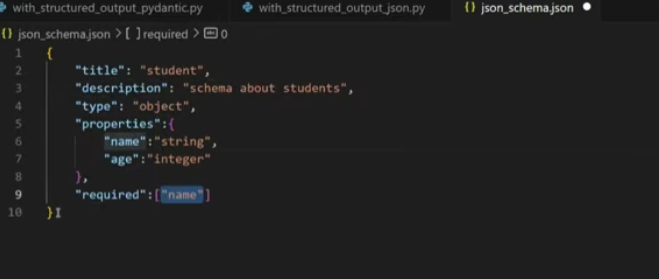

### When to use what

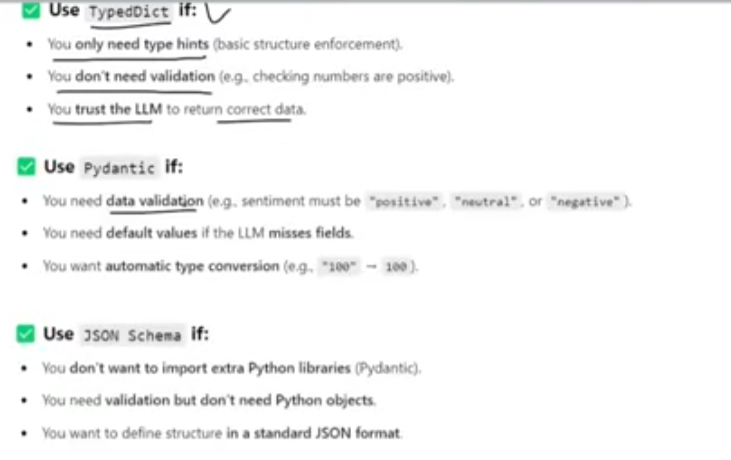

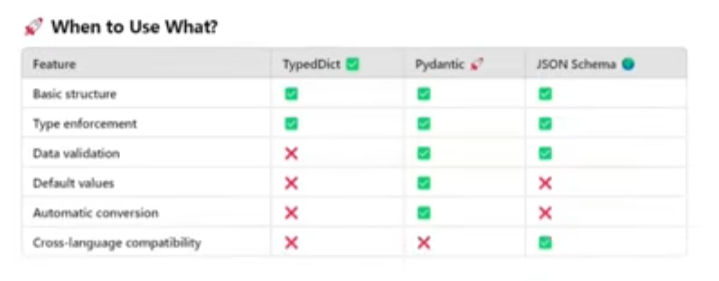

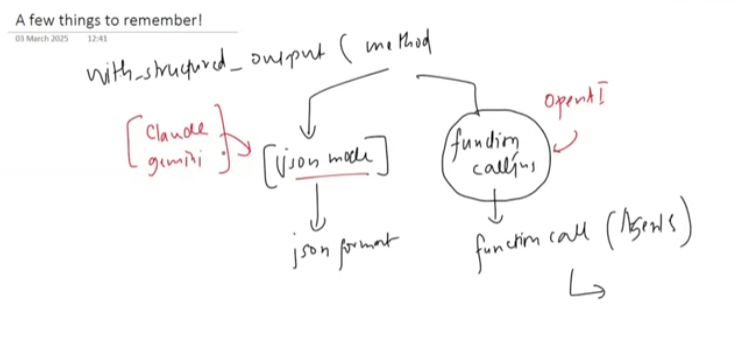